In [ ]:
# import os
# import pandas as pd
# import numpy as np

# result_dir = './result/ablation/TEA'
figure_dir = './figure/ablation/TEA'
# condition_dirs = ['AE', 'HDUR', 'DEC', 'DUCMME']
# condition_names = ['AE', 'HDUR', 'DEC', 'DUCMME']
# metric_mapping = {'Clustering ACC': 'ACC', 'Clustering NMI': 'NMI', 'Clustering ASW': 'ASW', 'Clustering RI': 'RI', 'Clustering ARI': 'ARI', 'Clustering Purity': 'Purity'}
# metrics = ['ACC', 'NMI', 'ASW', 'RI', 'ARI', 'PS']
# data = {}
# std_data = {}
# for cond_dir, cond_name in zip(condition_dirs, condition_names):
#     csv_path = os.path.join(result_dir, cond_dir, 'clustering_result.csv')
#     df = pd.read_csv(csv_path, index_col=0)
#     mean_row = df.mean()
#     std_row = df.std()
#     cond_values = []
#     cond_stds = []
#     for csv_col, metric in metric_mapping.items():
#         value = mean_row[csv_col]
#         std = std_row[csv_col]
#         cond_values.append(value)
#         cond_stds.append(std)
#     data[cond_name] = cond_values
#     std_data[cond_name] = cond_stds
#     # print(f"{cond_name}: ACC={cond_values[0]:.2f}, NMI={cond_values[1]:.2f}, ASW={cond_values[2]:.2f}, ARI={cond_values[3]:.2f}")
# print("conditions =", condition_names)
# print("metrics =", metrics)
# print("data =", data)
# print("std_data =", std_data)

# df_value = pd.DataFrame(index=condition_names, columns=metrics)
# for i, metric in enumerate(metrics):
#     df_value[metric] = [data[cond][i] for cond in condition_names]
# df_value.to_csv(os.path.join(result_dir, 'ablation_study_results_value.csv'), float_format='%.4f')
# df_value.to_csv(os.path.join(figure_dir, 'ablation_study_results_value.csv'), float_format='%.4f')
# df_std = pd.DataFrame(index=condition_names, columns=metrics)
# for i, metric in enumerate(metrics):
#     df_std[metric] = [std_data[cond][i] for cond in condition_names]
# df_std.to_csv(os.path.join(result_dir, 'ablation_study_results_std.csv'), float_format='%.4f')
# df_std.to_csv(os.path.join(figure_dir, 'ablation_study_results_std.csv'), float_format='%.4f')

conditions = ['AE', 'HDUR', 'DEC', 'DUCMME']
metrics = ['ACC', 'NMI', 'ASW', 'RI', 'ARI', 'PS']
data = {'AE': [57.60215542579457, 61.131267606026235, 30.935209488868715, 82.99409488221885, 44.58848985477739, 69.40356624995101], 'HDUR': [66.79797781870909, 66.51668352065761, 36.32906088829041, 87.70696509431545, 52.45291185293414, 77.93847239095506], 'DEC': [64.4735744797586, 61.64955128101948, 44.63556806558569, 75.00743273899029, 49.36155137107498, 64.09281707832733], 'DUCMME': [80.30358584473096, 73.48192076371863, 62.75833923816681, 89.28098429970638, 64.81026803029089, 80.29326331465299]}
std_data = {'AE': [6.206500693593125, 4.05793845331228, 4.676551761251449, 2.9725147133371776, 5.511382091714741, 4.184390923008294], 'HDUR': [2.0298776767333213, 1.4097871035149452, 0.7624943191629375, 0.6792824102131225, 2.5877931436212833, 2.6517699266842287], 'DEC': [9.275113550723994, 8.332141619429859, 9.68379298544774, 5.5966541760806825, 8.124102536917684, 9.148356461779082], 'DUCMME': [1.

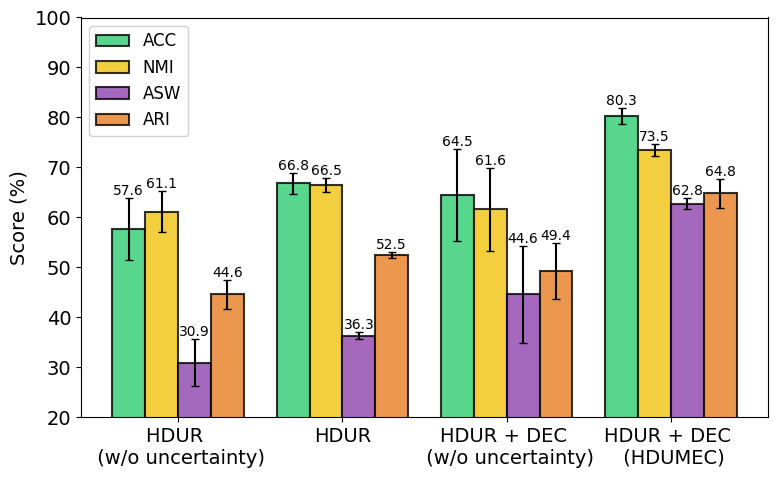

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14
result_dir = './result/ablation/TEA'
data_dir = './figure/ablation/TEA'
os.makedirs(data_dir, exist_ok=True)
df_value_loaded = pd.read_csv(os.path.join(figure_dir, 'ablation_study_results_value.csv'), index_col=0)
df_value_loaded = df_value_loaded[['ACC', 'NMI', 'ASW', 'ARI']]
df_std_loaded = pd.read_csv(os.path.join(figure_dir, 'ablation_study_results_std.csv'), index_col=0)
df_value_loaded = df_value_loaded[['ACC', 'NMI', 'ASW', 'ARI']]
data = {}
std_data = {}
conditions_names = df_value_loaded.index.tolist()
metrics = df_value_loaded.columns.tolist()
for cond in conditions_names:
    data[cond] = df_value_loaded.loc[cond].tolist()
    std_data[cond] = df_std_loaded.loc[cond].tolist()
condition_names_dict = {'AE': 'HDUR \n (w/o uncertainty)', 'HDUR': 'HDUR', 'DEC': 'HDUR + DEC \n (w/o uncertainty)', 'DUCMME': 'HDUR + DEC \n (HDUMEC)'}
values = np.array([[data[cond][i] for cond in conditions_names] for i in range(len(metrics))])
std_values = np.array([[std_data[cond][i] for cond in conditions_names] for i in range(len(metrics))])
x = np.arange(len(conditions_names))
width = 0.2  # Width of bars
colors = ['#2ECC71', '#F1C40F', '#8E44AD', '#E67E22', '#3498DB', '#9B59B6']  # Colors for each metric
plt.figure(figsize=(8, 5))
bars = []
for i, metric in enumerate(metrics):
    offset = (i - len(metrics)/2 + 0.5) * width
    bar = plt.bar(x + offset, values[i], yerr=std_values[i], width=width, label=metric, color=colors[i], alpha=0.8, edgecolor='black', linewidth=1.5, error_kw={'elinewidth': 1.5, 'capthick': 1}, capsize=3)
    bars.append(bar)
    for j, rect in enumerate(bar):
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width()/2., height+std_values[i][j], f'{height:.1f}', ha='center', va='bottom', fontsize=10, fontweight='normal')
# ax.set_xlabel('Conditions', fontweight='normal', fontsize=14)
plt.ylabel('Score (%)', fontweight='normal', fontsize=14)
# ax.set_title('Ablation Study', fontweight='normal', fontsize=14)
plt.xticks(x, [condition_names_dict[cond] for cond in conditions_names], fontsize=14)
plt.ylim(20, 100)
plt.legend(loc='upper left', fontsize=12, frameon=True, framealpha=0.9, facecolor='white', edgecolor=None)
# ax.grid(True, axis='y', alpha=0.3, linestyle='--')
plt.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(data_dir, 'stage_1_2_ablation_TEA.png'), dpi=400, bbox_inches='tight')
plt.show()